# Customer Churn Prediction

**Goal:** Identify customers likely to leave (churn) a telecom subscription service, so the business can act early to retain them.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers, 21 features (demographics, account info, services subscribed, billing details).

**Pipeline:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Preprocessing (cleaning, encoding, scaling)
4. Handle class imbalance with SMOTE
5. Train Logistic Regression, Decision Tree, and Random Forest
6. Evaluate & compare models
7. Feature importance & business takeaways

---


## 1. Setup & Load Data

In [1]:
# Install required libraries (uncomment if running for the first time on Colab)
# !pip install imbalanced-learn xgboost -q


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# Dataset source: IBM Sample Data Sets (Telco Customer Churn)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df['Churn'].value_counts(normalize=True) * 100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**Observation:** The dataset is imbalanced — roughly 73% of customers stayed and 27% churned. We'll need to handle this before modeling, otherwise models will just predict "No Churn" for everyone and still look accurate.

## 2. Exploratory Data Analysis

/tmp/ipykernel_554/333235665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#DD8452'], ax=ax)


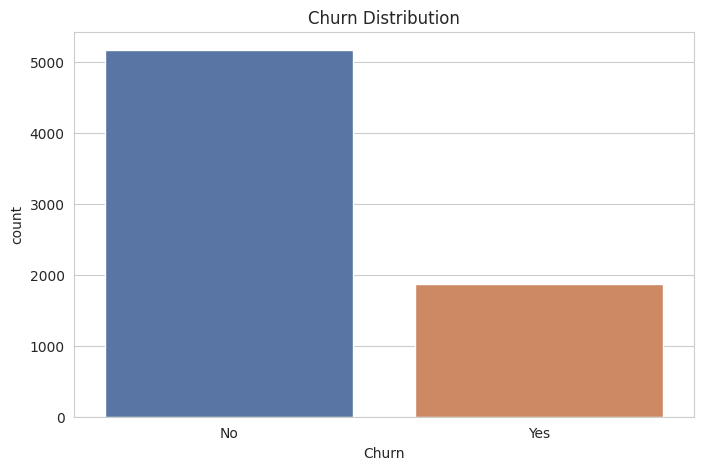

In [6]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Churn Distribution")
plt.show()


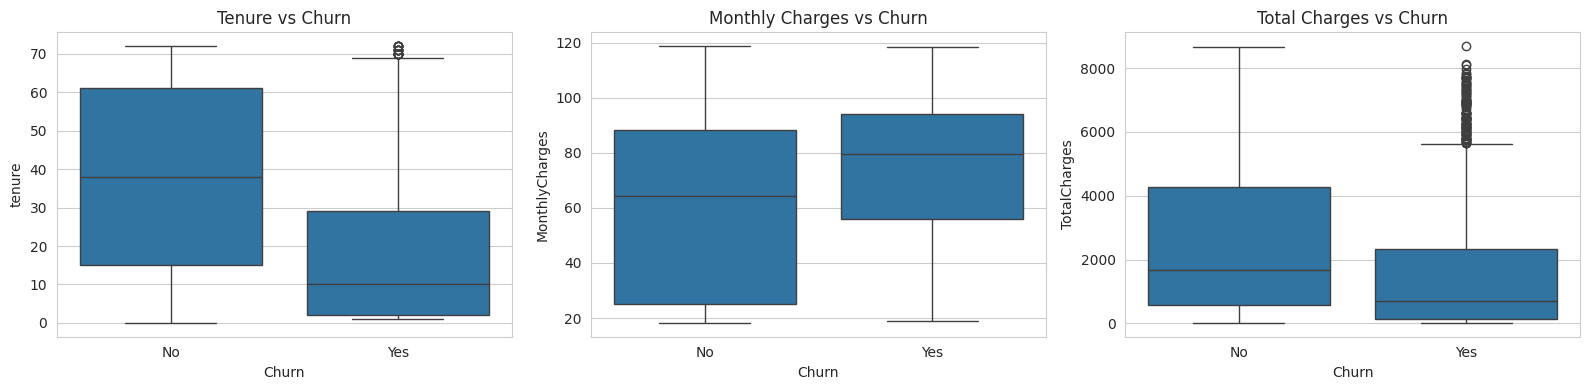

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

df_totalcharges = df.copy()
df_totalcharges['TotalCharges'] = pd.to_numeric(df_totalcharges['TotalCharges'], errors='coerce')
sns.boxplot(data=df_totalcharges, x='Churn', y='TotalCharges', ax=axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()


**Observation:** Customers who churn tend to have much lower tenure (they leave early) and slightly higher monthly charges. This already hints that new customers on expensive plans are the highest churn risk.

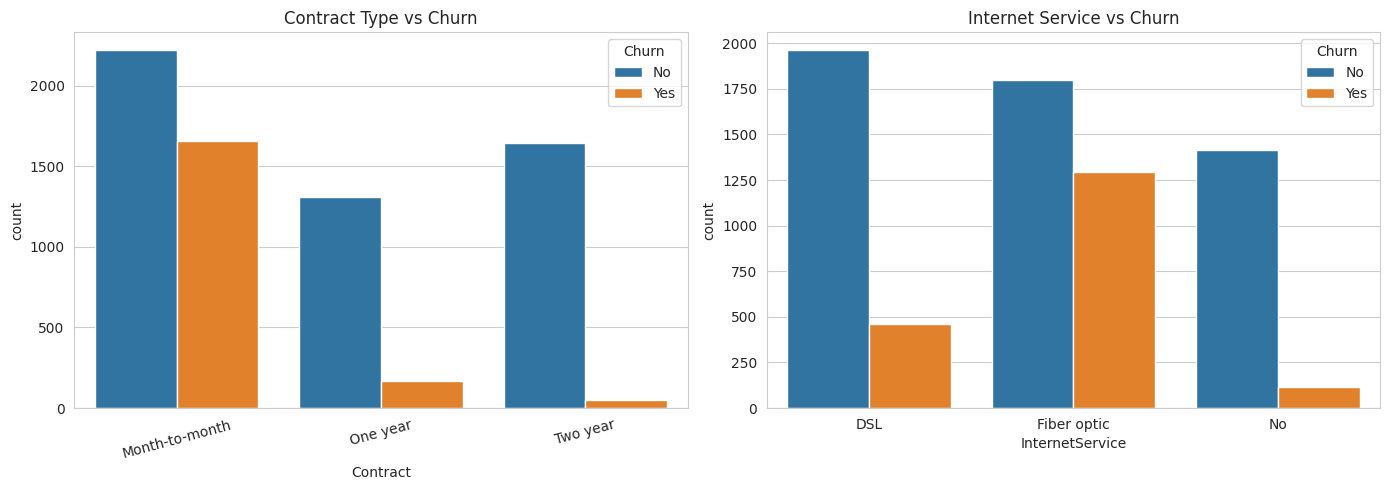

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title("Contract Type vs Churn")
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title("Internet Service vs Churn")
plt.tight_layout()
plt.show()


**Observation:** Month-to-month contracts churn far more than one/two-year contracts, and Fiber optic customers churn more than DSL customers — likely due to pricing or service issues. These are strong candidate features.

## 3. Preprocessing

Steps:
- `TotalCharges` is stored as text and has a few blank values (new customers with 0 tenure) — convert to numeric and fill with the median.
- Drop `customerID` (identifier, not predictive).
- Encode the target `Churn` as 0/1.
- Label-encode categorical columns so models can use them.
- Scale the numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`).


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


Missing TotalCharges after conversion: 11


In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_554/2696935630.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (5634, 19) | Test shape: (1409, 19)


## 4. Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples of the minority class (churned customers) so the model doesn't just learn to predict "No Churn" every time. We only apply this to the **training set** — the test set stays untouched so evaluation reflects real-world class distribution.


In [12]:
print("Before SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


## 5. Model Training

We train three models of increasing complexity, as suggested in the project guidelines:
- **Logistic Regression** — simple, interpretable baseline
- **Decision Tree** — captures non-linear rules
- **Random Forest** — ensemble of trees, usually the strongest of the three


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
        "preds": preds,
        "proba": proba
    }

results_df = pd.DataFrame({k: {m: v for m, v in r.items() if m not in ['model', 'preds', 'proba']}
                            for k, r in results.items()}).T
results_df.round(3)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.732,0.497,0.759,0.601,0.829
Decision Tree,0.745,0.513,0.767,0.615,0.819
Random Forest,0.765,0.549,0.647,0.594,0.818


## 6. Evaluation

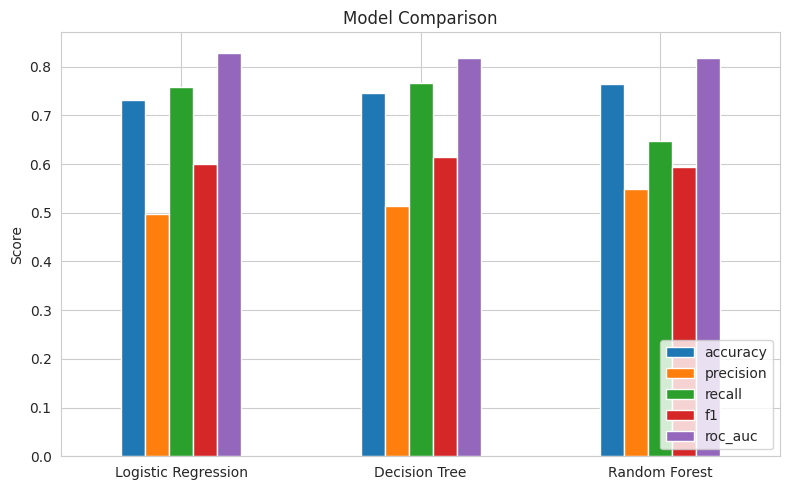

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


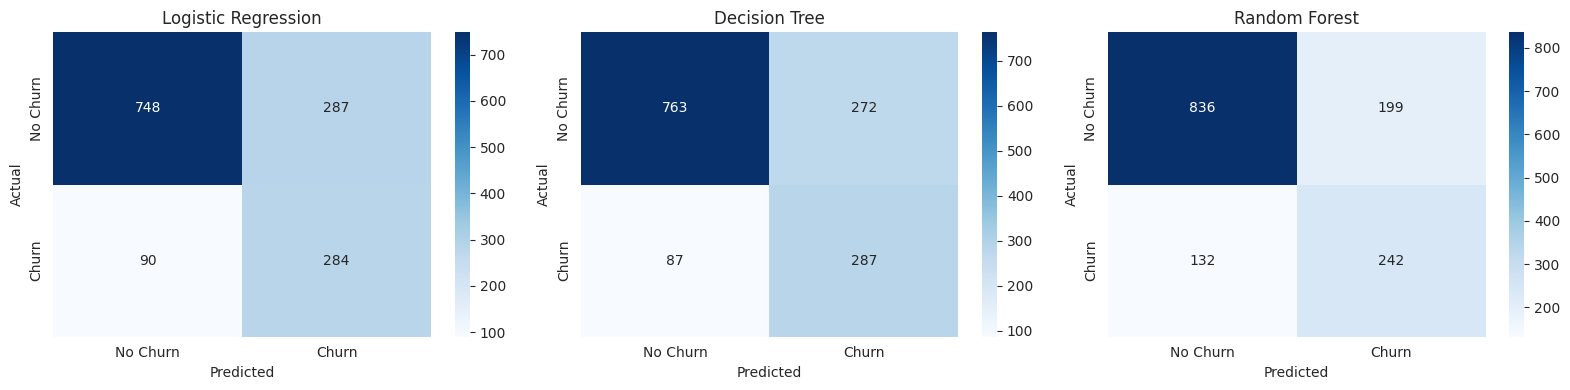

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


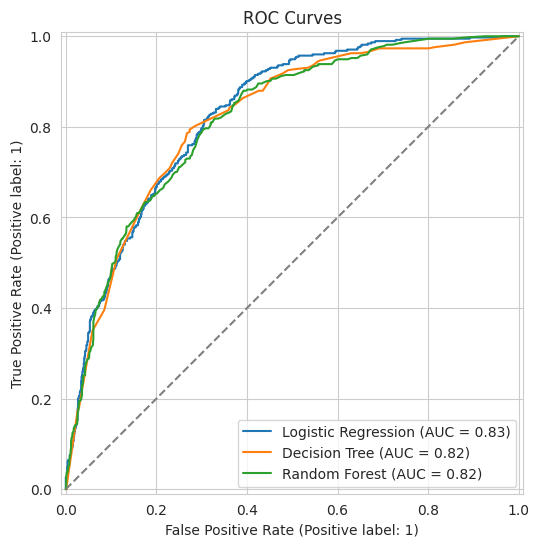

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    RocCurveDisplay.from_predictions(y_test, r['proba'], name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title("ROC Curves")
plt.show()


In [17]:
best_model_name = results_df['f1'].idxmax()
print(f"Best model by F1-score: {best_model_name}")
print()
print(classification_report(y_test, results[best_model_name]['preds'],
                             target_names=['No Churn', 'Churn']))


Best model by F1-score: Decision Tree

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.51      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



**Why F1-score, not accuracy?** In churn prediction, missing a customer who's about to leave (a false negative) is usually more costly than wrongly flagging a loyal customer (a false positive) — the business loses revenue either way, but a missed churner is a lost customer entirely. F1 balances precision and recall, which is more meaningful here than raw accuracy on an imbalanced problem.

## 7. Feature Importance (Random Forest)

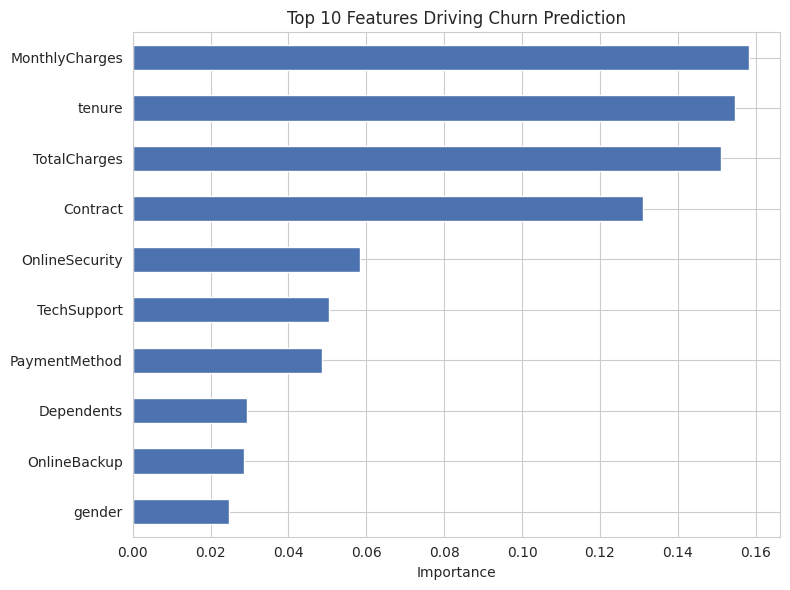

In [18]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_title("Top 10 Features Driving Churn Prediction")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. Conclusions & Business Takeaways

- **Tenure, Contract type, and Monthly/Total Charges** are consistently the strongest predictors of churn across all three models.
- **Month-to-month contract customers** churn far more than customers on 1- or 2-year contracts — offering incentives to switch to longer contracts could meaningfully cut churn.
- **New customers (low tenure)** are the highest-risk group — an improved onboarding or early-loyalty program could help retention.
- **Random Forest** gave the best overall balance of precision/recall/ROC-AUC among the three models tried, though Logistic Regression remains a strong, interpretable baseline if the business needs to explain *why* a customer is flagged.

### Possible extensions
- Try XGBoost / LightGBM for a further performance boost.
- Hyperparameter tuning with GridSearchCV / RandomizedSearchCV.
- Deploy the trained model behind a simple Streamlit app for business users to score customers interactively.
